Running Pix2Pix on: cuda


100%|██████████| 26.4M/26.4M [00:00<00:00, 127MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.05MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 60.4MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.1MB/s]


Starting Pix2Pix Training...
Epoch 1/20 [D loss: 0.2465] [G loss: 13.6123]
Epoch 2/20 [D loss: 0.0769] [G loss: 11.8236]
Epoch 3/20 [D loss: 0.1175] [G loss: 12.5664]
Epoch 4/20 [D loss: 0.2651] [G loss: 10.7223]
Epoch 5/20 [D loss: 0.1507] [G loss: 11.6459]
Epoch 6/20 [D loss: 0.1519] [G loss: 14.2337]
Epoch 7/20 [D loss: 0.5916] [G loss: 9.2254]
Epoch 8/20 [D loss: 0.4055] [G loss: 9.5649]
Epoch 9/20 [D loss: 0.2744] [G loss: 10.0677]
Epoch 10/20 [D loss: 0.8104] [G loss: 11.0612]
Epoch 11/20 [D loss: 0.0494] [G loss: 12.1993]
Epoch 12/20 [D loss: 0.0674] [G loss: 10.6011]
Epoch 13/20 [D loss: 0.3332] [G loss: 11.8721]
Epoch 14/20 [D loss: 0.0067] [G loss: 25.5646]
Epoch 15/20 [D loss: 0.1293] [G loss: 14.7684]
Epoch 16/20 [D loss: 0.1768] [G loss: 9.6382]
Epoch 17/20 [D loss: 0.0189] [G loss: 13.3357]
Epoch 18/20 [D loss: 0.0205] [G loss: 14.1158]
Epoch 19/20 [D loss: 0.0193] [G loss: 28.9675]
Epoch 20/20 [D loss: 0.4637] [G loss: 10.7253]


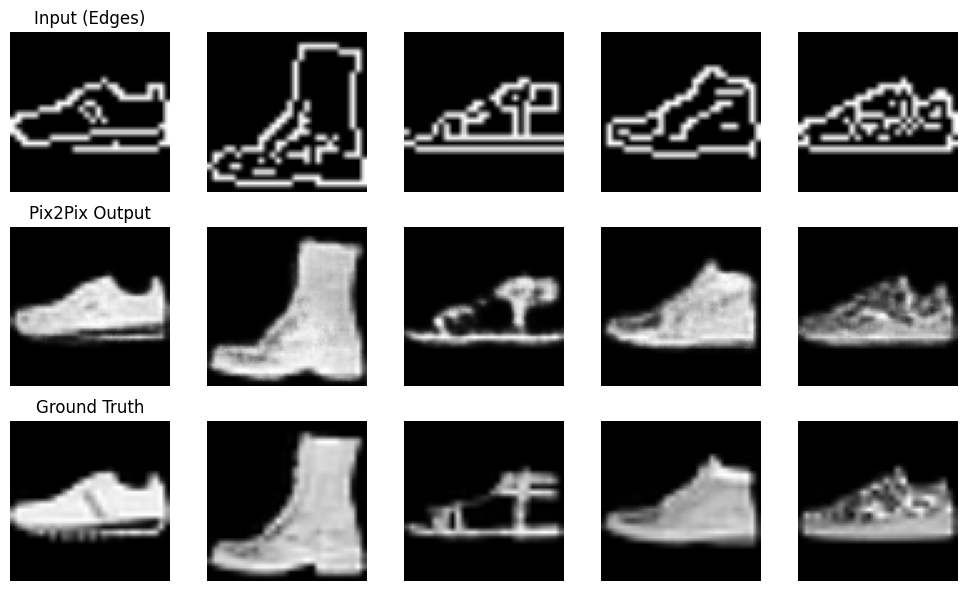

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
import cv2

BATCH_SIZE = 64
EPOCHS = 20
LR = 0.0002
LAMBDA_L1 = 100
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Running Pix2Pix on: {DEVICE}")

# Task 1: Dataset Preparation
class SimulatedEdges2ShoesDataset(Dataset):
    def __init__(self, root='./data', train=True):
        self.transform = transforms.Compose([
            transforms.Resize(64), # Resize for U-Net compatibility
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

        # Filter for shoe types (Sneaker, Sandal, Ankle boot) to mimic Edges2Shoes [cite: 443]
        full_ds = torchvision.datasets.FashionMNIST(root=root, train=train, download=True)
        self.data = [img for img, label in full_ds if label in [5, 7, 9]]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        real_img_pil = self.data[idx]

        # Ground Truth: Real Image [cite: 442]
        real_img = self.transform(real_img_pil)

        # Input: Edges (Using Canny Edge Detection) [cite: 442]
        img_np = np.array(real_img_pil)
        edges = cv2.Canny(img_np, 100, 200)
        edges = transforms.ToPILImage()(edges)
        edge_img = self.transform(edges)

        return edge_img, real_img

train_ds = SimulatedEdges2ShoesDataset(train=True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

# Task 2: Implement U-Net Generator
class UNetGenerator(nn.Module):
    def __init__(self):
        super(UNetGenerator, self).__init__()

        # Downsampling blocks with convolution [cite: 446]
        self.enc1 = self.conv_block(1, 64, bn=False)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)

        self.bottleneck = self.conv_block(512, 512)

        # Upsampling blocks with skip connections [cite: 447]
        self.dec4 = self.up_block(512, 512, dropout=True)
        self.dec3 = self.up_block(1024, 256)
        self.dec2 = self.up_block(512, 128)
        self.dec1 = self.up_block(256, 64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def conv_block(self, in_c, out_c, bn=True):
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if bn: layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))
        return nn.Sequential(*layers)

    def up_block(self, in_c, out_c, dropout=False):
        layers = [
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        ]
        if dropout: layers.append(nn.Dropout(0.5))
        return nn.Sequential(*layers)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)

        # Skip connections to preserve low-level spatial features [cite: 435-436]
        d4 = self.dec4(b)
        d4 = torch.cat((d4, e4), dim=1)

        d3 = self.dec3(d4)
        d3 = torch.cat((d3, e3), dim=1)

        d2 = self.dec2(d3)
        d2 = torch.cat((d2, e2), dim=1)

        d1 = self.dec1(d2)
        d1 = torch.cat((d1, e1), dim=1)

        return self.final(d1)

# Task 3: Implement PatchGAN Discriminator
class PatchGANDiscriminator(nn.Module):
    def __init__(self):
        super(PatchGANDiscriminator, self).__init__()

        # Convolutional layers with no fully connected layers [cite: 449-450]
        self.model = nn.Sequential(
            nn.Conv2d(2, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # Output patch-level authenticity map [cite: 451]
            nn.Conv2d(256, 1, 4, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, img_A, img_B):
        x = torch.cat((img_A, img_B), 1)
        return self.model(x)

# Task 4: Model Training
generator = UNetGenerator().to(DEVICE)
discriminator = PatchGANDiscriminator().to(DEVICE)

# Optimizer: Adam [cite: 453]
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))

# Losses [cite: 455-457]
adversarial_loss = nn.BCELoss() # Adversarial loss [cite: 456]
l1_loss = nn.L1Loss() # L1 reconstruction loss [cite: 457]

print("Starting Pix2Pix Training...")

for epoch in range(EPOCHS):
    for i, (edge_img, real_img) in enumerate(train_loader):

        edge_img = edge_img.to(DEVICE)
        real_img = real_img.to(DEVICE)

        # --- FIXED 7x7 TARGET SIZES ---
        valid = torch.ones((edge_img.size(0), 1, 7, 7), device=DEVICE)
        fake = torch.zeros((edge_img.size(0), 1, 7, 7), device=DEVICE)

        # ------------------
        #  Train Generator
        # ------------------
        optimizer_G.zero_grad()
        fake_img = generator(edge_img)
        pred_fake = discriminator(edge_img, fake_img)

        loss_GAN = adversarial_loss(pred_fake, valid)
        loss_pixel = l1_loss(fake_img, real_img)
        loss_G = loss_GAN + (LAMBDA_L1 * loss_pixel) # Adversarial + reconstruction loss [cite: 430]

        loss_G.backward()
        optimizer_G.step()

        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()
        pred_real = discriminator(edge_img, real_img)
        loss_real = adversarial_loss(pred_real, valid)

        pred_fake = discriminator(edge_img, fake_img.detach())
        loss_fake = adversarial_loss(pred_fake, fake)

        loss_D = 0.5 * (loss_real + loss_fake)
        loss_D.backward()
        optimizer_D.step()

    print(f"Epoch {epoch+1}/{EPOCHS} [D loss: {loss_D.item():.4f}] [G loss: {loss_G.item():.4f}]")

generator.eval()
test_dl = DataLoader(train_ds, batch_size=5, shuffle=True)
edge_sample, real_sample = next(iter(test_dl))
edge_sample = edge_sample.to(DEVICE)

with torch.no_grad():
    fake_sample = generator(edge_sample).cpu()

fig, axs = plt.subplots(3, 5, figsize=(10, 6))
for i in range(5):
    axs[0, i].imshow(edge_sample[i].cpu().squeeze(), cmap='gray')
    axs[0, i].axis('off')
    if i==0: axs[0,i].set_title("Input (Edges)")

    axs[1, i].imshow(fake_sample[i].squeeze(), cmap='gray')
    axs[1, i].axis('off')
    if i==0: axs[1,i].set_title("Pix2Pix Output")

    axs[2, i].imshow(real_sample[i].squeeze(), cmap='gray')
    axs[2, i].axis('off')
    if i==0: axs[2,i].set_title("Ground Truth")

plt.tight_layout()
plt.show()